# Práctica 1 — Modelo de pérdidas del ramo de Incendios
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Facultad de Ciencias, UNAM

**Equipo 08 · Ramo: Incendios**

---
Con la cartera de nuestro ramo, modelamos la **severidad** y la
**frecuencia**, simulamos la **pérdida agregada S** y sacamos de ahí la **prima pura preliminar**
del producto.

---
## 0. Entorno

In [26]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm

np.random.seed(8)   
plt.rcParams["figure.figsize"] = (9, 4)
print("✓ Entorno listo")

✓ Entorno listo


---
## 1. Cargar datos y explorar las variables de interés

Para esta práctica **solo nos importan algunas columnas**
(la agregada, sin factores de riesgo):

| Necesito para... | Variable | Qué es |
|---|---|---|
| Frecuencia | `num_siniestros`, `exposicion` | número de siniestros de la póliza y años-póliza expuestos |
| Severidad | `monto_promedio_siniestro` | monto ground-up (daño real) promedio por siniestro de la póliza |
| Transformar la póliza | `deducible`, `coaseguro`, `suma_asegurada` | condiciones del contrato, para pasar de severidad real a la que paga la aseguradora |

El resto de columnas (`tipo_inmueble`, `material_construccion`, `uso_inmueble`, `giro`,
`medidas_proteccion`, `antiguedad_inmueble`, `zona`) **existen pero no se usan en esta práctica**:
son los factores de riesgo por póliza que sí vamos a explotar en la Práctica 2 con un GLM.

In [27]:
df = pd.read_parquet("../inputs/cartera.parquet")
print(f"Pólizas: {len(df):,} | Columnas: {len(df.columns)}")
print("\nVariables que usamos en la Práctica 1:")
print("  frecuencia : num_siniestros, exposicion")
print("  severidad  : monto_promedio_siniestro (ground-up)")
print("  póliza     : deducible, suma_asegurada, coaseguro (para transformar)")
print("\nNo se usan aquí (factores de riesgo, para el GLM de la Práctica 2):")
print(" ", [c for c in df.columns if c not in
      ["id_poliza","exposicion","num_siniestros","monto_promedio_siniestro",
       "monto_total_siniestros","deducible","coaseguro","suma_asegurada"]])

Pólizas: 30,000 | Columnas: 15

Variables que usamos en la Práctica 1:
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (para transformar)

No se usan aquí (factores de riesgo, para el GLM de la Práctica 2):
  ['tipo_inmueble', 'material_construccion', 'uso_inmueble', 'giro', 'medidas_proteccion', 'antiguedad_inmueble', 'zona']


% de pólizas con siniestro : 2.81%
Distribución de num_siniestros:
num_siniestros
0    29156
1      814
2       30

Exposición total           : 24,006.2 años-póliza
Exposición por póliza      : media 0.800, rango [0.233, 0.999]

Severidad (monto_promedio_siniestro), solo pólizas con siniestro:
count         844.0
mean      1101539.0
std       3707539.0
min          2022.0
25%         83806.0
50%        260545.0
75%        742485.0
max      65619863.0


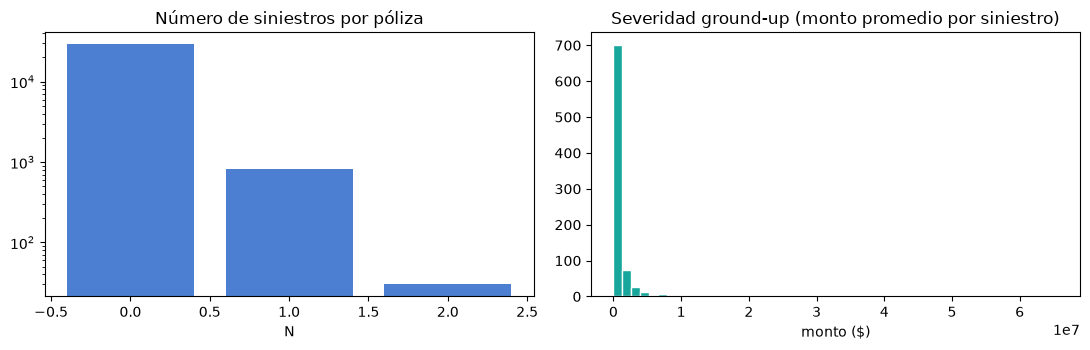

In [28]:
# ─── Exploración enfocada: solo número de siniestros, exposición y monto ───
con = df[df.num_siniestros > 0]                       # pólizas con al menos un siniestro

print(f"% de pólizas con siniestro : {(df.num_siniestros > 0).mean():.2%}")
print(f"Distribución de num_siniestros:\n{df.num_siniestros.value_counts().sort_index().to_string()}")
print(f"\nExposición total           : {df.exposicion.sum():,.1f} años-póliza")
print(f"Exposición por póliza      : media {df.exposicion.mean():.3f}, rango [{df.exposicion.min():.3f}, {df.exposicion.max():.3f}]")
print(f"\nSeveridad (monto_promedio_siniestro), solo pólizas con siniestro:")
print(con.monto_promedio_siniestro.describe().round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
vals, cts = np.unique(df.num_siniestros, return_counts=True)
ax[0].bar(vals, cts, color="#4C7FD1")
ax[0].set_title("Número de siniestros por póliza"); ax[0].set_xlabel("N"); ax[0].set_yscale("log")
ax[1].hist(con.monto_promedio_siniestro, bins=50, color="#17A69B", edgecolor="white")
ax[1].set_title("Severidad ground-up (monto promedio por siniestro)"); ax[1].set_xlabel("monto ($)")
plt.tight_layout(); plt.show()

La cartera de Incendios es una cartera de **baja frecuencia** (solo ~2.8% de las
pólizas reportan algún siniestro en el periodo, casi todas con un único siniestro) y **severidad
muy sesgada**: la mediana está muy por debajo de la media, señal de una cola pesada — típico del
ramo, donde la mayoría de los siniestros son daños menores pero unos pocos son pérdidas totales del
inmueble.

---
## 2. Severidad

Para modelar la severidad utilizamos `monto_promedio_siniestro` únicamente en las
pólizas que presentaron al menos un siniestro. Esta variable representa la severidad
**ground-up**, es decir, el monto real del daño antes de aplicar las condiciones de la póliza.

De acuerdo con la guía del ramo, Incendio se caracteriza por una severidad alta y de
cola pesada, ya que pueden presentarse pocos siniestros de montos muy elevados.

Por ello, ajustaremos las distribuciones **Lognormal, Gamma, Weibull y Pareto** y
compararemos su desempeño mediante el **AIC** y el comportamiento de la **cola**.

In [29]:
# ─── Severidad ground-up ────────────────────────────────────────────────

x = con["monto_promedio_siniestro"].dropna().values
x = x[x > 0]

media = x.mean()
mediana = np.median(x)
cv = x.std(ddof=1) / media
razon = media / mediana

print(f"Número de observaciones de severidad : {len(x):,}")
print(f"Media                              : ${media:,.0f}")
print(f"Mediana                            : ${mediana:,.0f}")
print(f"Media / mediana                    : {razon:.2f}")
print(f"Coeficiente de variación           : {cv:.2f}")
print(f"Máximo observado                   : ${x.max():,.0f}")

Número de observaciones de severidad : 844
Media                              : $1,101,539
Mediana                            : $260,545
Media / mediana                    : 4.23
Coeficiente de variación           : 3.37
Máximo observado                   : $65,619,863


### Exploración de la severidad

La severidad presenta un fuerte sesgo hacia la derecha. La media de los siniestros es de aproximadamente $1.10 millones, mientras que la mediana es de alrededor de $260 mil, por lo que la media resulta aproximadamente 4.23 veces mayor que la mediana.

Además, el coeficiente de variación es 3.37 y el monto máximo observado alcanza aproximadamente $65.6 millones. Esto indica una elevada dispersión y la presencia de algunos siniestros de gran magnitud que incrementan considerablemente la media.

Este comportamiento es consistente con el perfil del ramo de Incendio, que se caracteriza por una severidad alta y una cola pesada, debido a que pueden ocurrir pocos siniestros muy costosos e incluso pérdidas totales.

In [30]:
# ─── Ajuste de distribuciones de severidad ──────────────────────────────

def calcular_aic(dist, params, datos):
    log_verosimilitud = np.sum(dist.logpdf(datos, *params))
    k = len(params)
    return 2 * k - 2 * log_verosimilitud


candidatas = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto
}

ajustes = {}
resultados = []

for nombre, dist in candidatas.items():

    params = dist.fit(x, floc=0)

    ajustes[nombre] = (dist, params)

    resultados.append({
        "Distribución": nombre,
        "AIC": calcular_aic(dist, params, x)
    })


tabla_aic = pd.DataFrame(resultados)
tabla_aic = tabla_aic.sort_values("AIC").reset_index(drop=True)

tabla_aic["Delta AIC"] = tabla_aic["AIC"] - tabla_aic["AIC"].min()

tabla_aic["AIC"] = tabla_aic["AIC"].round(1)
tabla_aic["Delta AIC"] = tabla_aic["Delta AIC"].round(1)

print(tabla_aic.to_string(index=False))

mejor_aic = tabla_aic.loc[0, "Distribución"]

print(f"\nMejor distribución únicamente por AIC: {mejor_aic}")

Distribución     AIC  Delta AIC
   Lognormal 24309.7        0.0
     Weibull 24460.7      151.0
       Gamma 24648.0      338.3
      Pareto 25385.6     1075.9

Mejor distribución únicamente por AIC: Lognormal


### Comparación mediante AIC

Entre las distribuciones ajustadas, la **Lognormal** presenta el menor valor de AIC
(24309.7), seguida por Weibull, Gamma y Pareto.

Las diferencias de AIC respecto de la Lognormal son amplias, especialmente para Gamma
y Pareto, por lo que la Lognormal ofrece el mejor ajuste global entre las distribuciones
consideradas.

Sin embargo, dado que el ramo de Incendio se caracteriza por una cola pesada, la
selección final no se realizará únicamente con el AIC. También se analizará visualmente
el comportamiento de las distribuciones en la cola.

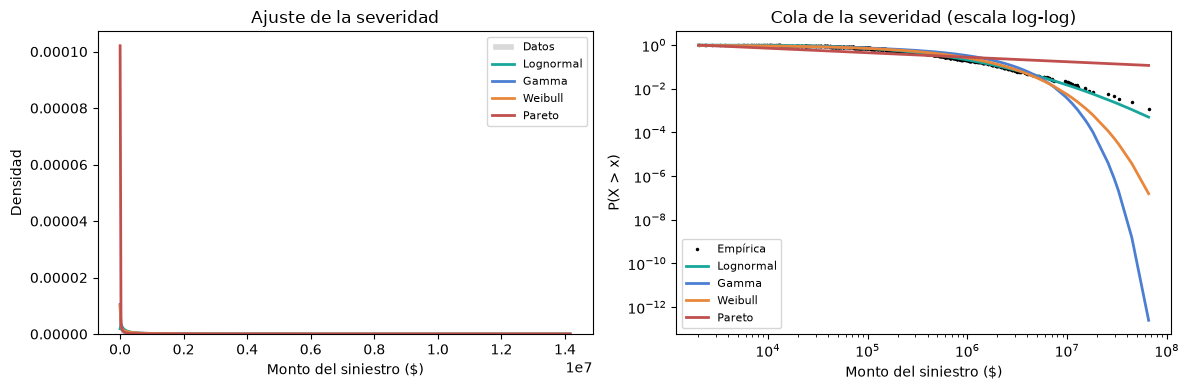

In [31]:
# ─── Diagnóstico gráfico: ajuste y comportamiento de la cola ────────────

colores = {
    "Lognormal": "#17A69B",
    "Gamma": "#4C7FD1",
    "Weibull": "#E8873C",
    "Pareto": "#C0504D"
}

# Percentil 99 para visualizar mejor el cuerpo de los datos
p99 = np.percentile(x, 99)
grid = np.linspace(x.min(), p99, 500)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# ── Histograma + densidades ajustadas ──
ax[0].hist(
    x,
    bins=70,
    density=True,
    range=(x.min(), p99),
    color="#d9d9d9",
    edgecolor="white",
    label="Datos"
)

for nombre, (dist, params) in ajustes.items():
    ax[0].plot(
        grid,
        dist.pdf(grid, *params),
        color=colores[nombre],
        lw=2,
        label=nombre
    )

ax[0].set_title("Ajuste de la severidad")
ax[0].set_xlabel("Monto del siniestro ($)")
ax[0].set_ylabel("Densidad")
ax[0].legend(fontsize=8)


# ── Función de supervivencia: cola ──
xs = np.sort(x)

S_emp = 1 - np.arange(1, len(xs) + 1) / (len(xs) + 1)

ax[1].plot(
    xs,
    S_emp,
    ".",
    color="black",
    markersize=3,
    label="Empírica"
)

for nombre, (dist, params) in ajustes.items():
    ax[1].plot(
        xs,
        dist.sf(xs, *params),
        color=colores[nombre],
        lw=2,
        label=nombre
    )

ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[1].set_title("Cola de la severidad (escala log-log)")
ax[1].set_xlabel("Monto del siniestro ($)")
ax[1].set_ylabel("P(X > x)")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Selección de la distribución de severidad

La distribución **Lognormal** fue seleccionada para modelar la severidad ground-up
del ramo de Incendio.

Por un lado, presentó el menor AIC (24309.7), con diferencias considerables respecto
a Weibull, Gamma y Pareto, por lo que proporciona el mejor ajuste global entre las
distribuciones consideradas.

Por otro lado, el análisis de la función de supervivencia muestra que la Lognormal
representa mejor el comportamiento de la cola empírica. La Gamma y la Weibull
disminuyen demasiado rápido para los montos elevados, lo que podría subestimar la
probabilidad de siniestros grandes. En contraste, la Pareto presenta una cola
demasiado pesada y sobreestima la probabilidad de pérdidas extremas.

Por lo tanto, considerando conjuntamente el AIC y el comportamiento de la cola,
elegimos la **Lognormal** como modelo de severidad para la cartera de Incendio.

In [32]:
# ─── Distribución seleccionada para la severidad ────────────────────────

mejor = "Lognormal"

dist_sev, pr_sev = ajustes[mejor]

print(f"Distribución seleccionada : {mejor}")
print(f"Parámetros estimados       : {pr_sev}")

Distribución seleccionada : Lognormal
Parámetros estimados       : (np.float64(1.6849641995627767), 0, np.float64(257111.70215221363))


In [33]:
# ─── Medidas del modelo de severidad seleccionado ──────────────────────

media_modelo = dist_sev.mean(*pr_sev)

var99_sev = dist_sev.ppf(0.99, *pr_sev)

tvar99_sev = dist_sev.expect(
    lambda z: z,
    args=pr_sev[:-2],
    loc=pr_sev[-2],
    scale=pr_sev[-1],
    lb=var99_sev,
    conditional=True
)

print(f"Media empírica        : ${x.mean():,.0f}")
print(f"Media del modelo      : ${media_modelo:,.0f}")
print(f"VaR 99% severidad     : ${var99_sev:,.0f}")
print(f"TVaR 99% severidad    : ${tvar99_sev:,.0f}")

Media empírica        : $1,101,539
Media del modelo      : $1,063,226
VaR 99% severidad     : $12,956,120
TVaR 99% severidad    : $21,950,477


c:\Users\Mafer Marin Marquez\anaconda3\envs\MASDFR\Lib\site-packages\scipy\stats\_distn_infrastructure.py:3047: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  dub = integrate.quad(fun, d, ub, **kwds)[0]


### Efecto de las condiciones de la póliza

Hasta este punto se modeló la severidad **ground-up**, es decir, el daño real ocasionado
por el siniestro. Sin embargo, este monto no necesariamente coincide con lo que paga
la aseguradora.

Para obtener la severidad a cargo de la compañía se aplican las condiciones de cada
póliza: deducible, coaseguro y suma asegurada.

In [34]:
# ─── Transformación de la severidad según la póliza ─────────────────────

def transformar_severidad(x, deducible, coaseguro, suma_asegurada):

    # Se resta el deducible
    despues_deducible = np.maximum(x - deducible, 0)

    # El asegurado absorbe la proporción indicada por el coaseguro
    despues_coaseguro = despues_deducible * (1 - coaseguro)

    # La aseguradora no puede pagar más que la suma asegurada
    pago_aseguradora = np.minimum(
        despues_coaseguro,
        suma_asegurada
    )

    return pago_aseguradora


pagado = transformar_severidad(
    con["monto_promedio_siniestro"].values,
    con["deducible"].values,
    con["coaseguro"].values,
    con["suma_asegurada"].values
)

media_ground = x.mean()
media_pagada = pagado.mean()

reduccion = 1 - media_pagada / media_ground

print(f"Severidad media ground-up        : ${media_ground:,.0f}")
print(f"Pago medio de la aseguradora     : ${media_pagada:,.0f}")
print(f"Reducción por condiciones póliza : {reduccion:.1%}")
print(f"Siniestros con pago igual a cero : {(pagado == 0).mean():.1%}")

Severidad media ground-up        : $1,101,539
Pago medio de la aseguradora     : $521,373
Reducción por condiciones póliza : 52.7%
Siniestros con pago igual a cero : 16.6%


### Efecto de las condiciones de la póliza

La severidad media **ground-up**, es decir, el daño real antes de aplicar las
condiciones del contrato, es de aproximadamente **$1,101,539** por siniestro.

Después de aplicar el deducible, el coaseguro y la suma asegurada, el pago medio
de la aseguradora disminuye a aproximadamente **$521,373**. Esto representa una
reducción de **52.7%** respecto de la severidad ground-up, por lo que la compañía
paga en promedio alrededor del **47.3% del daño original**.

Además, aproximadamente **16.6% de los siniestros generan un pago igual a cero**,
principalmente porque el monto del daño no supera el deducible correspondiente.

Estos resultados muestran que las condiciones de la póliza tienen un efecto
importante sobre la severidad asumida por la aseguradora: el deducible elimina
parte de los siniestros pequeños, el coaseguro reduce el monto que queda a cargo
de la compañía y la suma asegurada limita las pérdidas de mayor magnitud.

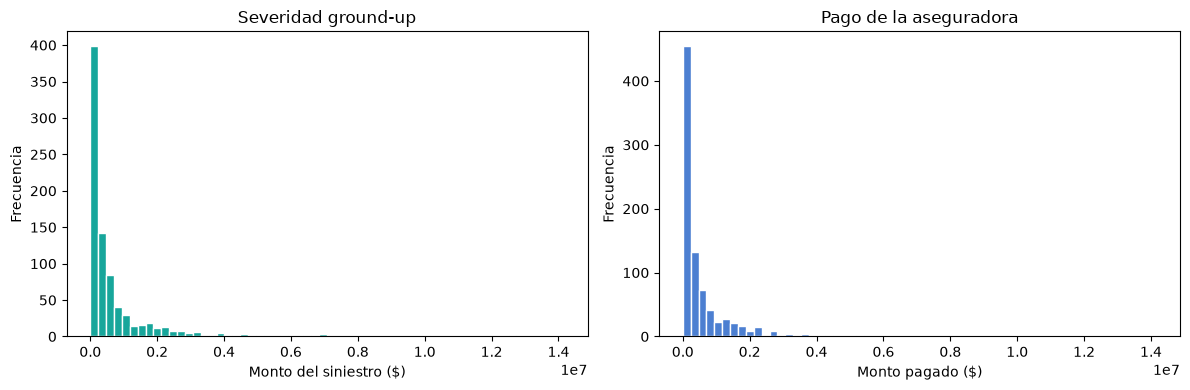

In [35]:
# ─── Ground-up vs pago de la aseguradora ────────────────────────────────

limite = np.percentile(x, 99)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Severidad real
ax[0].hist(
    x,
    bins=60,
    range=(0, limite),
    color="#17A69B",
    edgecolor="white"
)

ax[0].set_title("Severidad ground-up")
ax[0].set_xlabel("Monto del siniestro ($)")
ax[0].set_ylabel("Frecuencia")


# Severidad pagada
ax[1].hist(
    pagado,
    bins=60,
    range=(0, limite),
    color="#4C7FD1",
    edgecolor="white"
)

ax[1].set_title("Pago de la aseguradora")
ax[1].set_xlabel("Monto pagado ($)")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

---
## 3. Frecuencia — Inciso C

Para modelar la frecuencia utilizamos `num_siniestros` y la exposición de cada póliza.

La tasa de siniestros no se obtiene como un promedio simple del número de siniestros,
sino como:

$$
\hat{\lambda}
=
\frac{\sum_i N_i}{\sum_i e_i}
$$

donde \(N_i\) es el número de siniestros de la póliza \(i\) y \(e_i\) es su exposición.

Comparamos los modelos **Poisson** y **Binomial Negativa** utilizando la exposición
como `offset`. Además, revisamos la dispersión y la proporción de ceros para determinar
si existen señales de sobredispersión o inflación de ceros.

Aunque la guía de ramos señala a Poisson como una distribución típica para la frecuencia
de Incendio, la selección final se realizará con base en los resultados observados en
nuestra cartera.


In [36]:
# ─── Frecuencia: datos y exposición ─────────────────────────────────────

# Continuamos utilizando df, que ya fue cargado al inicio del notebook.
# No volvemos a leer el parquet para mantener el notebook reproducible.

n_observado = df["num_siniestros"].to_numpy()
exposicion = df["exposicion"].to_numpy()

# Tasa global por año-póliza
lambda_hat = n_observado.sum() / exposicion.sum()

# Media esperada de cada póliza bajo Poisson
mu_i = exposicion * lambda_hat


print(f"Número de pólizas        : {len(df):,}")
print(f"Siniestros observados    : {n_observado.sum():,}")
print(f"Exposición total         : {exposicion.sum():,.2f} años-póliza")
print(f"Tasa por año-póliza      : {lambda_hat:.8f}")

Número de pólizas        : 30,000
Siniestros observados    : 874
Exposición total         : 24,006.24 años-póliza
Tasa por año-póliza      : 0.03640721


In [37]:
# ─── Diagnóstico descriptivo de dispersión ──────────────────────────────

media_n = n_observado.mean()
varianza_n = n_observado.var(ddof=1)

indice_dispersion = varianza_n / media_n


print(f"Media del número de siniestros     : {media_n:.6f}")
print(f"Varianza del número de siniestros  : {varianza_n:.6f}")
print(f"Índice de dispersión Var/Media     : {indice_dispersion:.4f}")


if indice_dispersion > 1.05:
    print("→ Se observa sobredispersión respecto a Poisson.")
elif indice_dispersion < 0.95:
    print("→ Se observa subdispersión respecto a Poisson.")
else:
    print("→ La dispersión es cercana a la de un modelo Poisson.")

Media del número de siniestros     : 0.029133
Varianza del número de siniestros  : 0.030286
Índice de dispersión Var/Media     : 1.0396
→ La dispersión es cercana a la de un modelo Poisson.


In [38]:
# ─── Poisson y quasi-Poisson con exposición como offset ─────────────────

y = n_observado
offset = np.log(exposicion)

# Solo intercepto:
# todavía no usamos factores de riesgo en la Práctica 1.
X = np.ones((len(df), 1))


# Poisson
modelo_poisson = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=offset
).fit()


# Quasi-Poisson:
# se utiliza como diagnóstico de dispersión
modelo_quasi = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=offset
).fit(scale="X2")


lambda_poisson = np.exp(modelo_poisson.params[0])
phi = modelo_quasi.scale

mu_poisson = lambda_poisson * exposicion


print(f"Tasa estimada Poisson λ̂       : {lambda_poisson:.8f}")
print(f"Factor de dispersión φ         : {phi:.4f}")

if phi > 1.05:
    print("→ φ > 1: existe evidencia de sobredispersión.")
else:
    print("→ φ está próximo a 1: la sobredispersión no es fuerte.")

Tasa estimada Poisson λ̂       : 0.03640721
Factor de dispersión φ         : 1.0341
→ φ está próximo a 1: la sobredispersión no es fuerte.


In [39]:
# ─── Binomial Negativa con offset de exposición ─────────────────────────

modelo_nb = sm.NegativeBinomial(
    y,
    X,
    offset=offset
).fit(disp=0)


# Statsmodels usa:
# Var(N_i) = mu_i + alpha * mu_i^2

lambda_nb = np.exp(modelo_nb.params[0])
alpha_nb = modelo_nb.params[-1]

# Conversión a la parametrización de scipy.stats.nbinom
r_hat = 1 / alpha_nb

mu_i = lambda_nb * exposicion
p_i = r_hat / (r_hat + mu_i)


print(f"Tasa Binomial Negativa λ̂ : {lambda_nb:.8f}")
print(f"alpha estimado            : {alpha_nb:.8f}")
print(f"r estimado                : {r_hat:.8f}")
print(f"Convergencia              : {modelo_nb.mle_retvals['converged']}")

Tasa Binomial Negativa λ̂ : 0.03640040
alpha estimado            : 1.35008135
r estimado                : 0.74069610
Convergencia              : True


In [40]:
# ─── Comparación Poisson vs Binomial Negativa ───────────────────────────

aic_poisson = modelo_poisson.aic
aic_nb = modelo_nb.aic

tabla_frecuencia = pd.DataFrame({
    "Modelo": [
        "Poisson",
        "Binomial Negativa"
    ],
    "Log-verosimilitud": [
        modelo_poisson.llf,
        modelo_nb.llf
    ],
    "AIC": [
        aic_poisson,
        aic_nb
    ]
})

display(
    tabla_frecuencia.style.format({
        "Log-verosimilitud": "{:,.2f}",
        "AIC": "{:,.2f}"
    })
)


print(f"Reducción de AIC con NB: {aic_poisson - aic_nb:.2f}")

,Modelo,Log-verosimilitud,AIC
0,Poisson,"-3,972.66","7,947.32"
1,Binomial Negativa,"-3,964.42","7,932.83"


Reducción de AIC con NB: 14.49


In [41]:
# ─── Diagnóstico de exceso de ceros ─────────────────────────────────────

ceros_observados = (y == 0).mean()

# P(N=0) de cada póliza bajo Poisson
prob_cero_poisson = np.exp(-mu_poisson)
ceros_poisson = prob_cero_poisson.mean()


# P(N=0) de cada póliza bajo Binomial Negativa
prob_cero_nb = stats.nbinom.pmf(
    0,
    r_hat,
    p_i
)

ceros_nb = prob_cero_nb.mean()


print(f"P(N=0) observada             : {ceros_observados:.4%}")
print(f"P(N=0) esperada Poisson      : {ceros_poisson:.4%}")
print(f"P(N=0) esperada NB           : {ceros_nb:.4%}")

print(
    f"\nDiferencia observada - Poisson: "
    f"{(ceros_observados - ceros_poisson):+.4%}"
)

P(N=0) observada             : 97.1867%
P(N=0) esperada Poisson      : 97.1296%
P(N=0) esperada NB           : 97.1855%

Diferencia observada - Poisson: +0.0570%


### Diagnóstico de ceros

La cartera presenta una proporción muy alta de pólizas sin siniestro, lo cual es
esperable en el ramo de Incendio debido a su baja frecuencia.

Sin embargo, una proporción alta de ceros no implica automáticamente que sea
necesario utilizar un modelo de inflación de ceros. Para comprobarlo, comparamos
la proporción observada con la esperada bajo los modelos ajustados.

La proporción de ceros predicha por Poisson resulta muy cercana a la observada,
por lo que no encontramos evidencia importante de inflación adicional de ceros.
En consecuencia, no consideramos necesario utilizar un modelo ZIP para esta
cartera.

In [42]:
# ─── Distribución observada vs modelos ──────────────────────────────────

kmax = int(y.max())
ks = np.arange(0, kmax + 1)


# Proporción realmente observada
observado = (
    np.bincount(
        y.astype(int),
        minlength=kmax + 1
    )
    / len(y)
)


# Esperado bajo Poisson
esperado_poisson = np.array([
    np.mean(
        stats.poisson.pmf(k, mu_poisson)
    )
    for k in ks
])


# Esperado bajo Binomial Negativa
esperado_nb = np.array([
    np.mean(
        stats.nbinom.pmf(k, r_hat, p_i)
    )
    for k in ks
])


tabla_ajuste_frecuencia = pd.DataFrame({
    "Número de siniestros": ks,
    "Observado": observado,
    "Poisson": esperado_poisson,
    "Binomial Negativa": esperado_nb
})

display(
    tabla_ajuste_frecuencia.style.format({
        "Observado": "{:.5f}",
        "Poisson": "{:.5f}",
        "Binomial Negativa": "{:.5f}"
    })
)

,Número de siniestros,Observado,Poisson,Binomial Negativa
0,0,0.97187,0.97130,0.97185
1,1,0.02713,0.02828,0.02720
2,2,0.00100,0.00042,0.00091


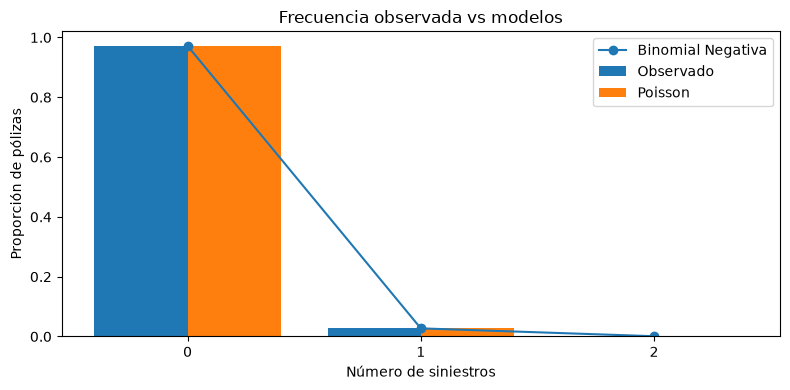

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))


ax.bar(
    ks - 0.20,
    observado,
    width=0.40,
    label="Observado"
)

ax.bar(
    ks + 0.20,
    esperado_poisson,
    width=0.40,
    label="Poisson"
)

ax.plot(
    ks,
    esperado_nb,
    "o-",
    label="Binomial Negativa"
)


ax.set_xlabel("Número de siniestros")
ax.set_ylabel("Proporción de pólizas")
ax.set_title("Frecuencia observada vs modelos")
ax.set_xticks(ks)

ax.legend()

plt.tight_layout()
plt.show()

In [44]:
# ─── Resumen del modelo de frecuencia seleccionado ──────────────────────

mejor_frecuencia = (
    "Binomial Negativa"
    if aic_nb < aic_poisson
    else "Poisson"
)


print("RESUMEN DEL INCISO C")
print()

print(f"Tasa por año-póliza             : {lambda_nb:.8f}")
print(f"Índice de dispersión Var/Media : {indice_dispersion:.4f}")
print(f"Factor quasi-Poisson phi       : {phi:.4f}")

print()

print(f"Ceros observados               : {ceros_observados:.4%}")
print(f"Ceros esperados Poisson        : {ceros_poisson:.4%}")
print(f"Ceros esperados NB             : {ceros_nb:.4%}")

print()

print(f"AIC Poisson                    : {aic_poisson:,.2f}")
print(f"AIC Binomial Negativa          : {aic_nb:,.2f}")
print(f"Diferencia de AIC              : {aic_poisson - aic_nb:,.2f}")

print()

print(f"Modelo seleccionado            : {mejor_frecuencia}")

RESUMEN DEL INCISO C

Tasa por año-póliza             : 0.03640040
Índice de dispersión Var/Media : 1.0396
Factor quasi-Poisson phi       : 1.0341

Ceros observados               : 97.1867%
Ceros esperados Poisson        : 97.1296%
Ceros esperados NB             : 97.1855%

AIC Poisson                    : 7,947.32
AIC Binomial Negativa          : 7,932.83
Diferencia de AIC              : 14.49

Modelo seleccionado            : Binomial Negativa


### Conclusión de frecuencia

La cartera de Incendio presenta una **frecuencia baja**, consistente con el perfil
esperado para este ramo. La tasa estimada es de aproximadamente **0.0364 siniestros
por año-póliza**.

El índice de dispersión es cercano a 1, por lo que los conteos no presentan una
sobredispersión extrema. El diagnóstico quasi-Poisson conduce a una conclusión
similar.

Asimismo, aunque aproximadamente **97.2% de las pólizas no presentan siniestros**,
la proporción de ceros esperada bajo Poisson es muy cercana a la observada.
Por esta razón no encontramos evidencia importante de inflación adicional de ceros
y no resulta necesario utilizar un modelo ZIP.

Al comparar formalmente los modelos de frecuencia, la **Binomial Negativa presenta
un AIC menor que Poisson**, con una diferencia de aproximadamente 14.5 puntos.
Por lo tanto, aunque Poisson describe razonablemente la baja frecuencia de la
cartera, la Binomial Negativa proporciona un mejor ajuste global.

En consecuencia, seleccionamos la **Binomial Negativa** como modelo de frecuencia
para la simulación de la pérdida agregada. Para cada póliza se conserva su exposición
individual mediante

\[
\mu_i=e_i\hat{\lambda},
\]

y los parámetros \(r\) y \(p_i\) obtenidos del modelo se utilizarán directamente
en la simulación del inciso D.

## 4. Pérdida agregada — Inciso D

**Pregunta de negocio:** ¿cuánto cuesta el daño de toda la cartera y cuánto paga la aseguradora?

Conectamos directamente la Lognormal de B ("dist_sev", "pr_sev") con la frecuencia de C ("r_hat", "p_i"). En cada réplica simulamos los siniestros de cada póliza y un monto por evento. Aplicamos la función "transformar_severidad" ya definida en B, usando el contrato de la póliza que originó cada siniestro.

$$S_{ground-up}=\sum_i\sum_j X_{ij},\qquad S_{aseguradora}=\sum_i\sum_j Y_{ij}.$$

Se mantiene el orden de B: **deducible → coaseguro → suma asegurada**. El deducible es un monto y el coaseguro es la fracción a cargo del asegurado:

$$Y_{ij}=\min\{(X_{ij}-d_i)_+(1-c_i),L_i\}.$$

**Convención contractual:** verificar este orden contra el contrato antes de tarificar. Se aplican límites por evento; no se modela agotamiento anual de la suma asegurada.

El periodo simulado conserva las exposiciones observadas (aproximadamente 24,006 años-póliza para 30,000 pólizas); no supone un año completo para todas. B ajustó promedios por póliza, que aquí se usan como aproximación de daños individuales. Se supone independencia entre eventos, entre pólizas y entre frecuencia y severidad.

In [45]:
# Configuración de Monte Carlo.
SEMILLA = 8
N_SIMULACIONES = 20_000
ALPHA = 0.99

sem_frecuencia, sem_severidad = np.random.SeedSequence(SEMILLA).spawn(2)
rng_frecuencia = np.random.default_rng(sem_frecuencia)
rng_severidad = np.random.default_rng(sem_severidad)

n_polizas = len(df)
indices_polizas = np.arange(n_polizas)
deducibles = df['deducible'].to_numpy()
coaseguros = df['coaseguro'].to_numpy()
sumas_aseguradas = df['suma_asegurada'].to_numpy()

S_ground_up = np.zeros(N_SIMULACIONES)
S_transformada = np.zeros(N_SIMULACIONES)
N_total = np.zeros(N_SIMULACIONES, dtype=int)
# Tarda aprox. unos 50 segundos.

In [46]:
# Un conteo por póliza; un monto de daño por siniestro.
for b in range(N_SIMULACIONES):
    n_i = rng_frecuencia.negative_binomial(r_hat, p_i)
    ids = np.repeat(indices_polizas, n_i)

    danos = dist_sev.rvs(*pr_sev, size=len(ids), random_state=rng_severidad)
    pagos = transformar_severidad(
        danos, deducibles[ids], coaseguros[ids], sumas_aseguradas[ids]
    )

    N_total[b] = len(ids)
    S_ground_up[b] = danos.sum()
    S_transformada[b] = pagos.sum()

S_retenida = S_ground_up - S_transformada
print(f'Simulación terminada: {N_SIMULACIONES:,} escenarios y {n_polizas:,} pólizas.')
print(f'Siniestros esperados: {mu_i.sum():,.2f}; promedio simulado: {N_total.mean():,.2f}')

Simulación terminada: 20,000 escenarios y 30,000 pólizas.
Siniestros esperados: 873.84; promedio simulado: 873.47


In [47]:
def metricas_riesgo(s):
    orden = np.sort(s)
    n = len(orden)
    pesos_cola = np.clip(np.arange(1, n + 1) - ALPHA * n, 0, 1)
    return {
        'E[S]': s.mean(),
        'VaR 99%': orden[int(np.ceil(ALPHA * n)) - 1],
        'TVaR 99%': np.dot(orden, pesos_cola) / pesos_cola.sum()
    }

metricas_ground = metricas_riesgo(S_ground_up)
metricas_pago = metricas_riesgo(S_transformada)
tabla_comparativa = pd.DataFrame({
    'Ground-up': metricas_ground,
    'Aseguradora': metricas_pago
})
tabla_comparativa['Reducción (%)'] = 100 * (1 - tabla_comparativa['Aseguradora'] / tabla_comparativa['Ground-up'])
display(tabla_comparativa)

porcentaje_pagado = 100 * S_transformada.mean() / S_ground_up.mean()
porcentaje_retenido = 100 - porcentaje_pagado
reparto = pd.DataFrame({
    'Parte': ['Aseguradora', 'Retenido / no cubierto'],
    'Pérdida esperada': [S_transformada.mean(), S_retenida.mean()],
    'Porcentaje del daño esperado': [porcentaje_pagado, porcentaje_retenido]
})
display(reparto)

,Ground-up,Aseguradora,Reducción (%)
E[S],9.276248e+08,4.591651e+08,50.500992
VaR 99%,1.309663e+09,5.348560e+08,59.160792
TVaR 99%,1.480216e+09,5.470954e+08,63.039484


,Parte,Pérdida esperada,Porcentaje del daño esperado
0,Aseguradora,4.591651e+08,49.499008
1,Retenido / no cubierto,4.684597e+08,50.500992


El porcentaje cubierto compara el **pago esperado con el daño esperado**, no promedia porcentajes de cada escenario. Lo retenido/no cubierto es el daño que queda fuera de esta póliza. El porcentaje puede diferir del obtenido en B, donde se usaron los montos observados, porque D simula toda la cartera con los modelos ajustados.

La **prima pura agregada del producto** es E[S transformada]: representa lo que espera pagar la compañía. La prima comercial o final también debe incluir gastos, comisiones, margen y costo de capital. El promedio por póliza que mostramos abajo corresponde a la exposición observada; no es una tarifa individual ni anualizada.

In [48]:
print(f'Prima pura agregada: ${S_transformada.mean():,.2f}')
print(f'Promedio por póliza en el periodo: ${S_transformada.mean() / n_polizas:,.2f}')
print(f'Porcentaje del daño esperado pagado: {porcentaje_pagado:.2f}%')
print(f'Porcentaje retenido/no cubierto: {porcentaje_retenido:.2f}%')

# Comprobación del promedio ground-up: E[S] = suma de medias de frecuencia × E[X].
esperanza_teorica_ground = mu_i.sum() * dist_sev.mean(*pr_sev)
error_mc_ground = S_ground_up.std(ddof=1) / np.sqrt(N_SIMULACIONES)
error_mc_pago = S_transformada.std(ddof=1) / np.sqrt(N_SIMULACIONES)
print(f'Ground-up esperado según el modelo: ${esperanza_teorica_ground:,.2f}')
print(f'Ground-up promedio simulado: ${S_ground_up.mean():,.2f}')
print(f'Error estándar Monte Carlo de la media ground-up: ${error_mc_ground:,.2f}')
print(f'Error estándar Monte Carlo de la media de pago: ${error_mc_pago:,.2f}')

Prima pura agregada: $459,165,062.24
Promedio por póliza en el periodo: $15,305.50
Porcentaje del daño esperado pagado: 49.50%
Porcentaje retenido/no cubierto: 50.50%
Ground-up esperado según el modelo: $929,085,652.89
Ground-up promedio simulado: $927,624,774.60
Error estándar Monte Carlo de la media ground-up: $910,242.96
Error estándar Monte Carlo de la media de pago: $215,496.84


### Distribución y estabilidad
Los histogramas muestran la variación del costo total. La curva de excedencia compara los escenarios de mayor pérdida. La media acumulada ayuda a observar si el promedio se estabiliza.

Con 20,000 simulaciones, el peor 1% equivale a 200 escenarios. La tabla por bloques permite revisar cuánto cambian los resultados de cola. El error estándar anterior mide error Monte Carlo de la media, no incertidumbre de los parámetros ni precisión del VaR o TVaR.

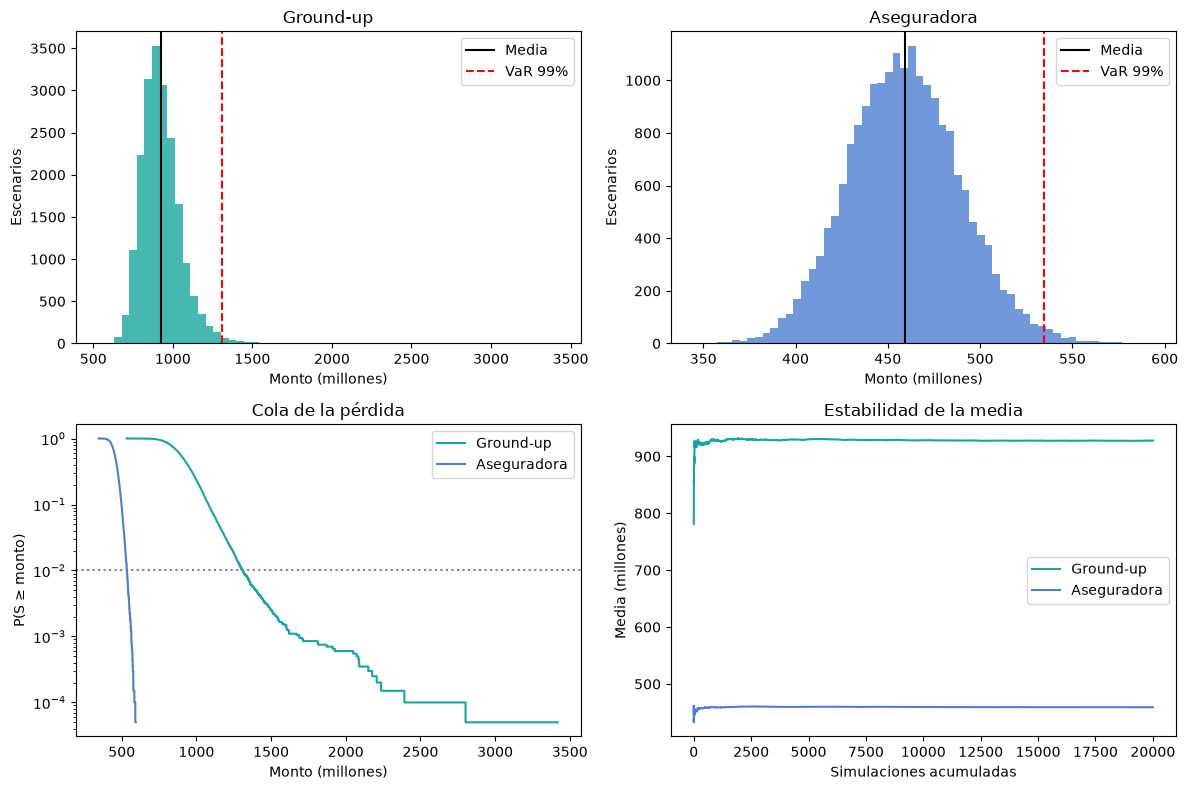

,Versión,Bloque,E[S],VaR 99%,TVaR 99%
0,Ground-up,1,9.299323e+08,1.312951e+09,1.460918e+09
1,Ground-up,2,9.266507e+08,1.309663e+09,1.503064e+09
2,Ground-up,3,9.261925e+08,1.304087e+09,1.442904e+09
3,Ground-up,4,9.277237e+08,1.304854e+09,1.513741e+09
4,Aseguradora,1,4.598208e+08,5.355246e+08,5.493387e+08
5,Aseguradora,2,4.592056e+08,5.359024e+08,5.481330e+08
6,Aseguradora,3,4.586670e+08,5.339769e+08,5.460907e+08
7,Aseguradora,4,4.589668e+08,5.332100e+08,5.445685e+08


In [49]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
series = [S_ground_up, S_transformada]
nombres = ['Ground-up', 'Aseguradora']
colores_d = ['#17A69B', '#4C7FD1']

for j, (s, nombre, color) in enumerate(zip(series, nombres, colores_d)):
    m = metricas_riesgo(s)
    ax[0, j].hist(s / 1e6, bins=60, color=color, alpha=0.8)
    ax[0, j].axvline(m['E[S]'] / 1e6, color='black', label='Media')
    ax[0, j].axvline(m['VaR 99%'] / 1e6, color='red', linestyle='--', label='VaR 99%')
    ax[0, j].set(title=nombre, xlabel='Monto (millones)', ylabel='Escenarios')
    ax[0, j].legend()

    orden = np.sort(s)
    excedencia = (len(s) - np.arange(len(s))) / len(s)
    ax[1, 0].step(orden / 1e6, excedencia, where='pre', label=nombre, color=color)
    media_acumulada = np.cumsum(s) / np.arange(1, len(s) + 1)
    ax[1, 1].plot(media_acumulada / 1e6, label=nombre, color=color)

ax[1, 0].set(yscale='log', title='Cola de la pérdida', xlabel='Monto (millones)', ylabel='P(S ≥ monto)')
ax[1, 0].axhline(0.01, color='gray', linestyle=':')
ax[1, 1].set(title='Estabilidad de la media', xlabel='Simulaciones acumuladas', ylabel='Media (millones)')
ax[1, 0].legend()
ax[1, 1].legend()
plt.tight_layout()
plt.show()

estabilidad = []
for nombre, s in zip(nombres, series):
    for numero, bloque in enumerate(np.array_split(s, 4), start=1):
        estabilidad.append({'Versión': nombre, 'Bloque': numero, **metricas_riesgo(bloque)})
display(pd.DataFrame(estabilidad))

### Impacto en el negocio
El daño total y el pago de la aseguradora responden a preguntas distintas. El primero mide la pérdida económica; el segundo es la base de la prima pura del producto. Los deducibles, coaseguros y límites reducen el costo y la exposición de la compañía, pero no eliminan el daño.

VaR y TVaR ayudan a estudiar escenarios adversos y decisiones de retención o reaseguro. No equivalen por sí solos al capital regulatorio ni a la prima comercial. Las diferencias entre cuantiles tampoco son los cuantiles de la pérdida retenida.

Estos resultados son preliminares: dependen del ajuste a promedios por póliza y de la independencia supuesta. No se modelan incendios que afecten varias pólizas simultáneamente. Antes de fijar una tarifa final conviene revisar esos supuestos y la estabilidad de las estimaciones de cola.

In [50]:
print("CONCLUSIONES DEL INCISO D")
print()

print(f"Daño esperado de la cartera: {S_ground_up.mean() / 1e6:,.2f} millones.")
print(f"Pago esperado de la aseguradora: {S_transformada.mean() / 1e6:,.2f} millones.")
print()

print(f"La aseguradora cubre el {porcentaje_pagado:.2f}% del daño esperado.")
print(f"El {porcentaje_retenido:.2f}% queda retenido o no cubierto.")
print()

print(f"VaR 99% del pago: {metricas_pago['VaR 99%'] / 1e6:,.2f} millones.")
print(f"TVaR 99% del pago: {metricas_pago['TVaR 99%'] / 1e6:,.2f} millones.")
print()

print("La prima pura agregada corresponde al pago esperado de la aseguradora.")
print("Para obtener la prima comercial, todavía faltan los recargos.")

CONCLUSIONES DEL INCISO D

Daño esperado de la cartera: 927.62 millones.
Pago esperado de la aseguradora: 459.17 millones.

La aseguradora cubre el 49.50% del daño esperado.
El 50.50% queda retenido o no cubierto.

VaR 99% del pago: 534.86 millones.
TVaR 99% del pago: 547.10 millones.

La prima pura agregada corresponde al pago esperado de la aseguradora.
Para obtener la prima comercial, todavía faltan los recargos.
